# Bloomberg Dataset Text Length Analysis

This notebook analyzes the distribution of headline and article lengths from the Bloomberg Financial News dataset.

## Setup

In [5]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import logging
import sys

# Set up logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger(__name__)

In [6]:
# Get the current directory
current_dir = Path.cwd()

# Go up one level to FYP
project_root = current_dir.parent.parent.parent
sys.path.append(str(project_root))
data_path = project_root / "data" / "raw" / "bloomberg" / "bloomberg_financial_data.parquet"

logger.info(f"Loading dataset from {data_path}")
df = pd.read_parquet(data_path)
print(f"Dataset shape: {df.shape}")
df.head()

2025-05-13 14:34:52,038 - INFO - Loading dataset from /Users/jasonlam/Desktop/github/FYP/data/raw/bloomberg/bloomberg_financial_data.parquet


Dataset shape: (446762, 5)


,Headline,Journalists,Date,Link,Article
0,"Ivory Coast Keeps Cocoa Export Tax Below 22%, ...",[Baudelaire Mieu],2011-10-06 15:14:20,http://www.bloomberg.com/news/2011-10-06/ivory...,"Export taxes on cocoa beans from Ivory Coast ,..."
1,USDA Boxed Beef Cutout Closing Prices for Octo...,[Michael Carone],2011-10-06 20:22:42,http://www.bloomberg.com/news/2011-10-06/usda-...,October 6 (Bloomberg) -- This table details bo...
2,U.S. September Small Business Jobs Summary,[Alex Tanzi],2011-10-06 19:00:00,http://www.bloomberg.com/news/2011-10-06/u-s-s...,U.S. small business plans to hire declined in ...
3,Greece’s GSEE Says Won’t Meet For Talks With T...,[Natalie Weeks],2011-10-06 14:45:34,http://www.bloomberg.com/news/2011-10-06/greec...,"Greece ’s biggest private sector union group, ..."
4,Clean-Tech Companies Should Get 10-Year Tax Br...,[Ari Levy],2011-10-06 18:34:41,http://www.bloomberg.com/news/2011-10-06/clean...,"Reed Hundt, head of the Coalition for Green Ca..."


Headline Token Statistics:
count    446762.000000
mean         14.861374
std           3.210445
min           0.000000
25%          13.000000
50%          15.000000
75%          17.000000
max          35.000000
Name: headline_tokens, dtype: float64

Article Token Statistics:
count    446762.000000
mean        609.064793
std         638.728381
min           5.000000
25%         220.000000
50%         447.000000
75%         816.000000
max       21882.000000
Name: article_tokens, dtype: float64


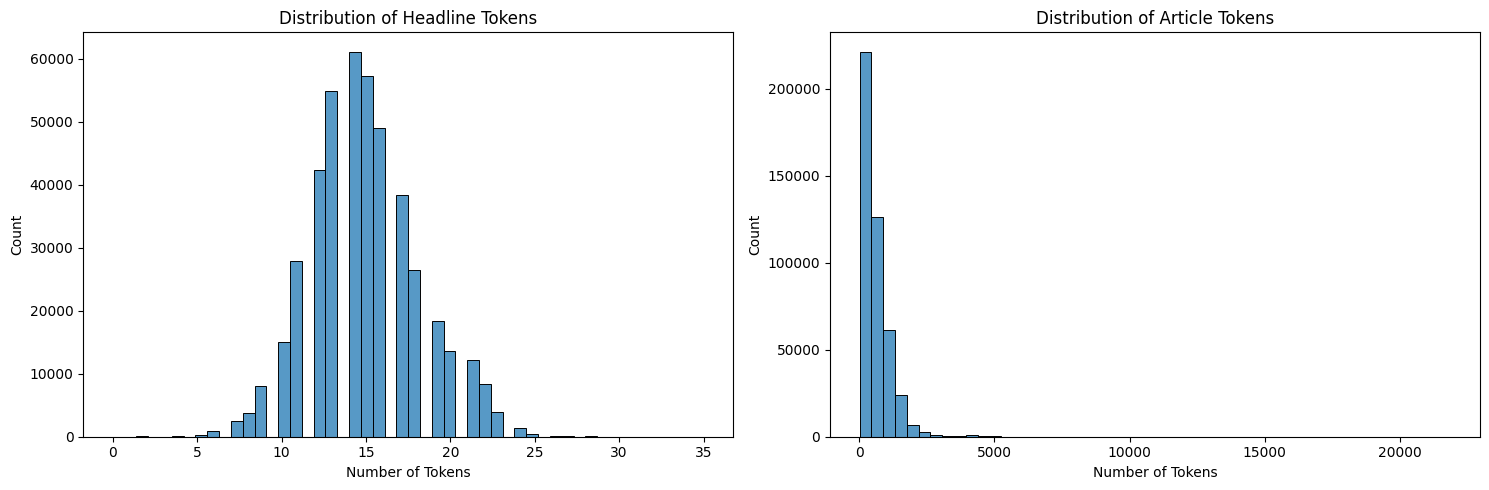

In [3]:
# Import tiktoken for token counting
import tiktoken

# Initialize the tokenizer (using cl100k_base which is used by GPT-4 and other models)
tokenizer = tiktoken.get_encoding("cl100k_base")

# Function to count tokens
def count_tokens(text):
    return len(tokenizer.encode(text))

# Calculate token lengths
df['headline_tokens'] = df['Headline'].apply(count_tokens)
df['article_tokens'] = df['Article'].apply(count_tokens)

# Display summary statistics
print("Headline Token Statistics:")
print(df['headline_tokens'].describe())
print("\nArticle Token Statistics:")
print(df['article_tokens'].describe())

# Optional: Show distribution of token counts
plt.figure(figsize=(15, 5))

# Plot headline token distribution
plt.subplot(1, 2, 1)
sns.histplot(data=df, x='headline_tokens', bins=50)
plt.title('Distribution of Headline Tokens')
plt.xlabel('Number of Tokens')
plt.ylabel('Count')

# Plot article token distribution
plt.subplot(1, 2, 2)
sns.histplot(data=df, x='article_tokens', bins=50)
plt.title('Distribution of Article Tokens')
plt.xlabel('Number of Tokens')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

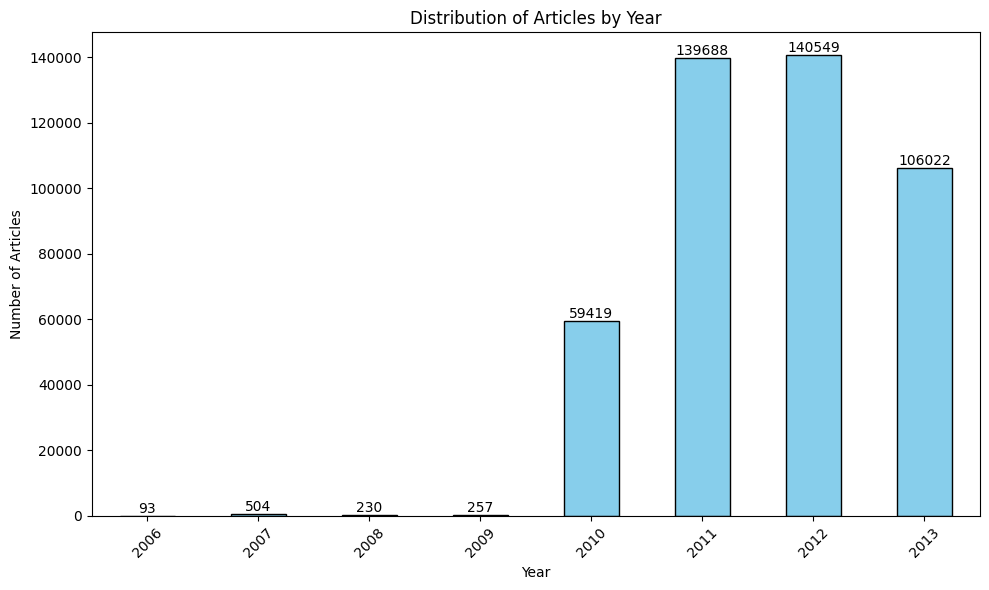

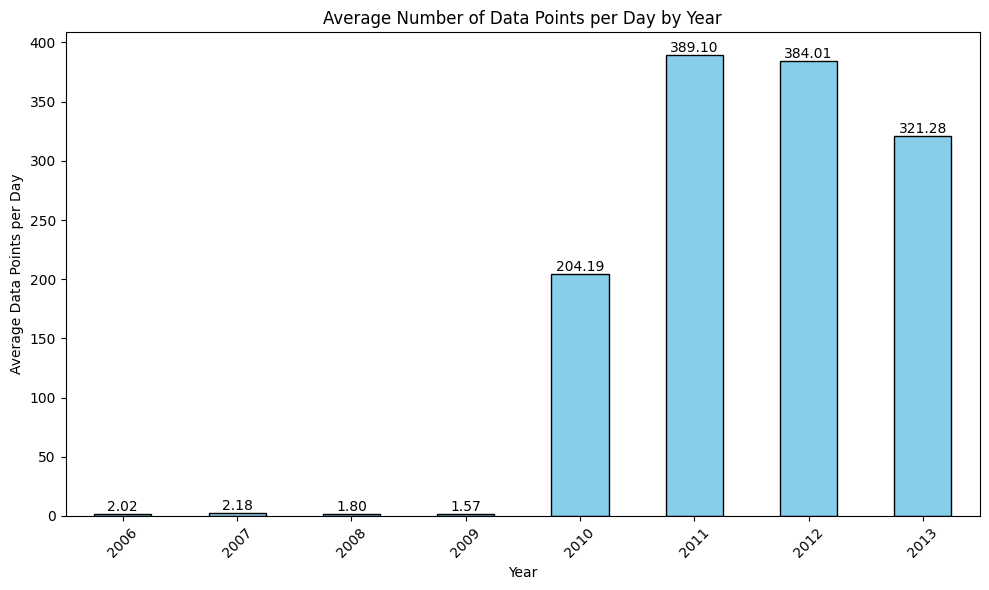

In [7]:
from src.utils.plot_df import plot_distribution_by_year, plot_description_length_distribution, plot_avg_per_day_by_year

plot_distribution_by_year(df, 'Date')
plot_avg_per_day_by_year(df, 'Date')

In [5]:
# Sort by date and remove duplicate headlines
print(f"Original dataset shape: {df.shape}")
old_count = df.shape[0]

# Sort by date in ascending order
df = df.sort_values('Date')

# Remove duplicates based on headline, keeping the first occurrence
df = df.drop_duplicates(subset=['Headline'], keep='first')

# Print results
print(f"Dataset shape after removing duplicates: {df.shape}")
print(f"Number of duplicates removed: {old_count - df.shape[0]}")

# Display the first few rows to verify the sorting
df.head()

Original dataset shape: (446762, 7)
Dataset shape after removing duplicates: (436870, 7)
Number of duplicates removed: 9892


,Headline,Journalists,Date,Link,Article,headline_tokens,article_tokens
45732,"Inco's Net Soars on Higher Metal Prices, Break...",[Dale Crofts],2006-10-20 20:16:16,http://www.bloomberg.com/news/2006-10-20/inco-...,"Inco Ltd., the Canadian nickel producer being ...",14,961
15839,"Jim Cramer: Diageo, Anheuser-Busch, Monster Wo...",[Steven Bodzin],2006-10-21 00:08:44,http://www.bloomberg.com/news/2006-10-21/jim-c...,Jim Cramer recommended that viewers buy shares...,18,680
259883,EU Energy Chief Backs German Plan for Price Co...,[Thomas Bauer],2006-10-23 11:51:36,http://www.bloomberg.com/news/2006-10-23/eu-en...,European Union Energy Commissioner Andris Pieb...,10,688
259882,Ex-Plant Worker Shuster Pleads Guilty in Tradi...,[David Glovin],2006-10-23 20:00:29,http://www.bloomberg.com/news/2006-10-23/ex-pl...,A former worker at a Wisconsin printing plant ...,13,596
255216,"Jim Cramer: Bare Escentuals, Allergan, Medicis...",[Steven Bodzin],2006-10-24 01:32:04,http://www.bloomberg.com/news/2006-10-24/jim-c...,"Bare Escentuals Inc.'s cosmetics are a fad, ma...",19,827


In [7]:
# Select and save specific columns to CSV
columns_to_save = ['Headline', 'Date', 'Link', 'Article']

# Create processed directory if it doesn't exist
processed_dir = Path('.').absolute().parent.parent.parent / "data" / "processed" / "bloomberg"
processed_dir.mkdir(parents=True, exist_ok=True)

# Define output path
output_path = processed_dir / "bloomberg_cleaned.csv"

# Save the selected columns to CSV
logger.info(f"Saving cleaned dataset to {output_path}")
df[columns_to_save].to_csv(output_path, index=False)
logger.info("Dataset saved successfully")

# Display the first few rows of the saved data
print("\nFirst few rows of the saved data:")
print(df[columns_to_save].head())

2025-05-12 21:06:26,055 - INFO - Saving cleaned dataset to /Users/jasonlam/Desktop/github/FYP/src/data/processed/bloomberg/bloomberg_financial_data_cleaned.csv
2025-05-12 21:07:05,863 - INFO - Dataset saved successfully



First few rows of the saved data:
                                                 Headline                Date  \
45732   Inco's Net Soars on Higher Metal Prices, Break... 2006-10-20 20:16:16   
15839   Jim Cramer: Diageo, Anheuser-Busch, Monster Wo... 2006-10-21 00:08:44   
259883  EU Energy Chief Backs German Plan for Price Co... 2006-10-23 11:51:36   
259882  Ex-Plant Worker Shuster Pleads Guilty in Tradi... 2006-10-23 20:00:29   
255216  Jim Cramer: Bare Escentuals, Allergan, Medicis... 2006-10-24 01:32:04   

                                                     Link  \
45732   http://www.bloomberg.com/news/2006-10-20/inco-...   
15839   http://www.bloomberg.com/news/2006-10-21/jim-c...   
259883  http://www.bloomberg.com/news/2006-10-23/eu-en...   
259882  http://www.bloomberg.com/news/2006-10-23/ex-pl...   
255216  http://www.bloomberg.com/news/2006-10-24/jim-c...   

                                                  Article  
45732   Inco Ltd., the Canadian nickel producer bei